In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.constants import mu_0
from simpeg import (
    simulation, data, data_misfit,
    regularization, optimization,
    inverse_problem, directives, inversion, maps
)
from geoana import utils, spatial
from geoana.em import static

In [2]:
def decay_law(t, k, alpha, beta, gamma):
    return k * (t + alpha)**(-beta) * np.exp(-t / gamma)

In [3]:
#decay to create dipole/pole plots, checking if all works
t = np.logspace(-2, 2, 10)
alpha = 0.0191
beta = 1.01
gamma = 22.4
k = 1
L = decay_law(t, k, alpha, beta, gamma)

print(L)
print(t)

[3.55855924e+01 2.19450531e+01 1.05683313e+01 4.28447263e+00
 1.58148204e+00 5.47293450e-01 1.71740841e-01 4.23371910e-02
 5.39364018e-03 1.09926292e-04]
[1.00000000e-02 2.78255940e-02 7.74263683e-02 2.15443469e-01
 5.99484250e-01 1.66810054e+00 4.64158883e+00 1.29154967e+01
 3.59381366e+01 1.00000000e+02]


In [4]:
mu = mu_0  # permeability of free space N/A^2
location = np.r_[0., 0., -10.]  # location of the dipole
# dipole parameters
moment = 1
# inclination and declination (Vancouver)
inclination, declination = 67., 0.

In [5]:
def id_to_cartesian(inclination, declination):
    ux = np.cos(inclination/180.*np.pi)*np.sin(declination/180.*np.pi)
    uy = np.cos(inclination/180.*np.pi)*np.cos(declination/180.*np.pi)
    uz = -np.sin(inclination/180.*np.pi)
    return np.r_[ux, uy, uz]

orientation = id_to_cartesian(inclination, declination)
dipole = static.MagneticDipoleWholeSpace(
    location=location,
    orientation=orientation,
    moment=moment
)

pole = static.MagneticPoleWholeSpace(
    location=location,
    orientation=orientation,
    moment=moment
)

In [6]:
x = np.linspace(-36, 36, 100)
y = np.linspace(-36, 36, 100)
xyz = utils.ndgrid([x, y, np.r_[1.]])

b_vec_dipole = dipole.magnetic_flux_density(xyz)
b_vec_pole = pole.magnetic_flux_density(xyz)
b_total_dipole = dipole.dot_orientation(b_vec_dipole)
b_total_pole = pole.dot_orientation(b_vec_pole)

In [7]:
def plot_amplitude(ax, v):
    plt.colorbar(
        ax.pcolormesh(
            x, y, v.reshape(len(x), len(y), order='F')
        ), ax=ax
    )
    ax.axis('square')
    ax.set_xlabel('y (east,  m)')
    ax.set_ylabel('x (north,  m)')

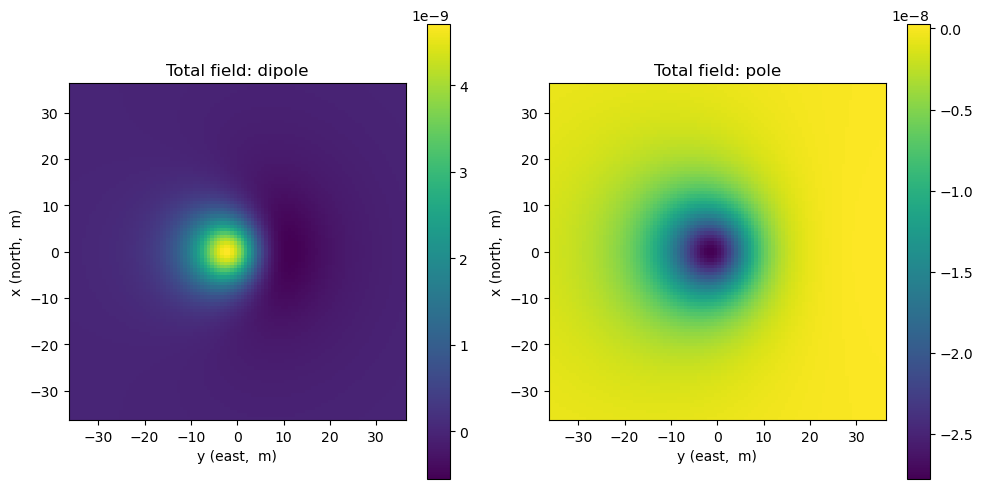

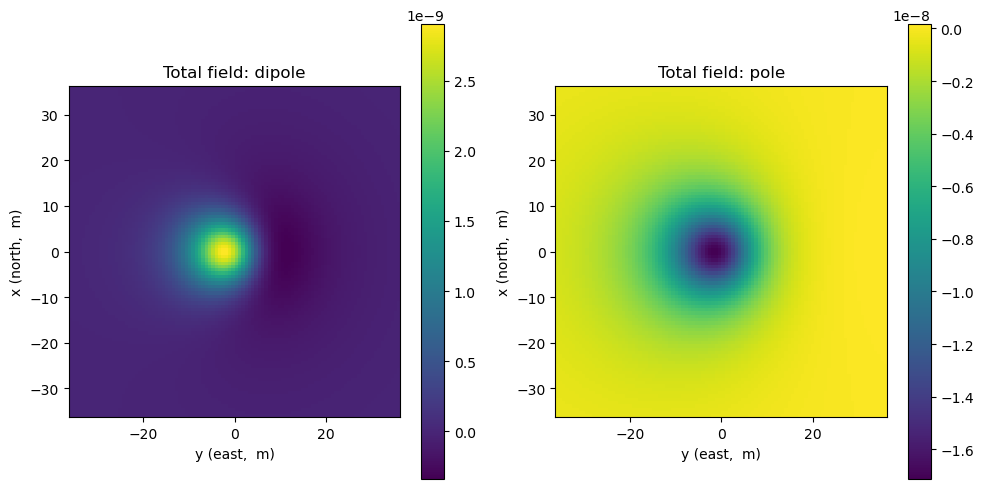

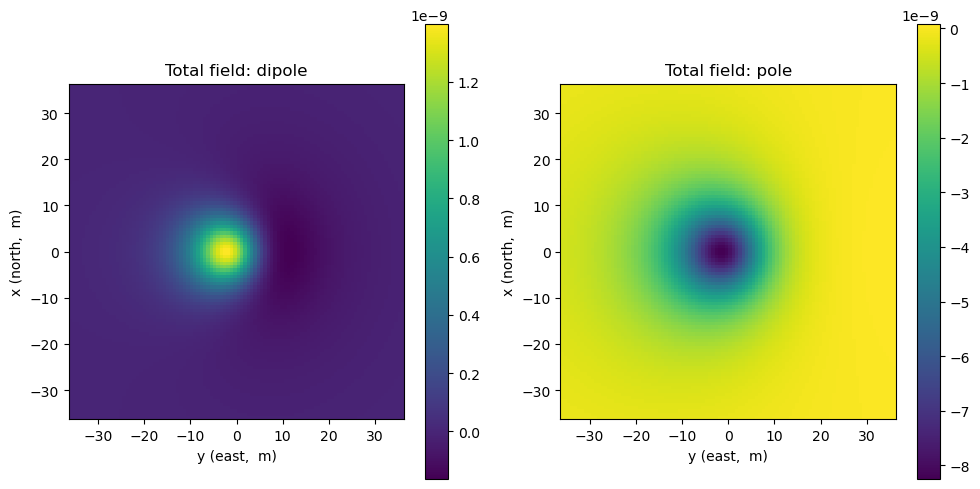

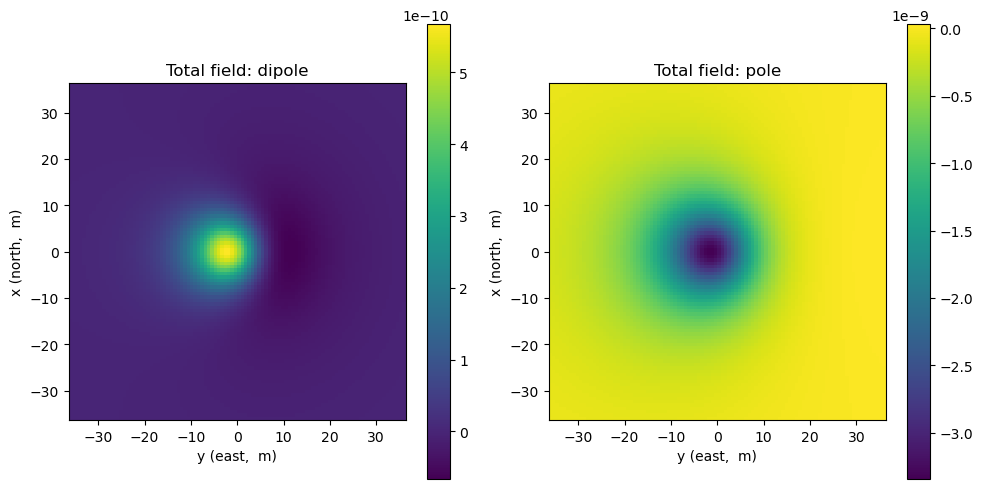

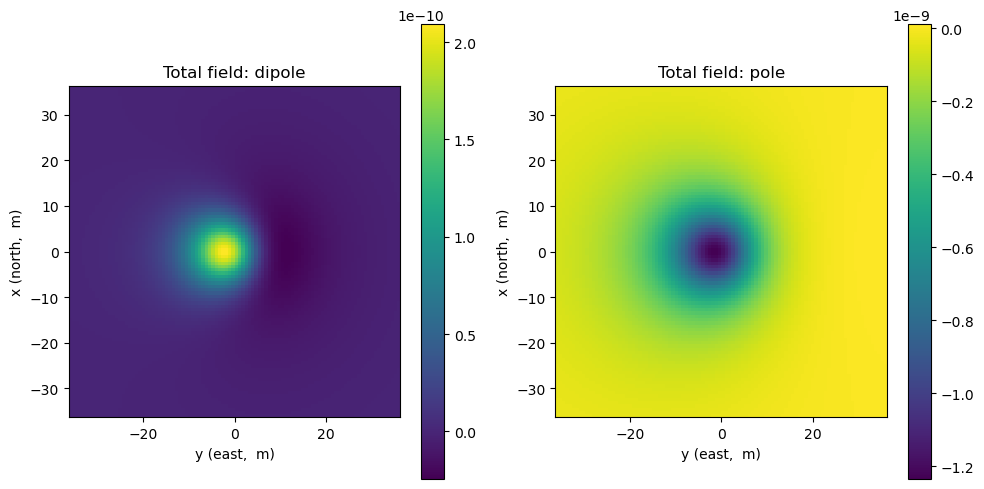

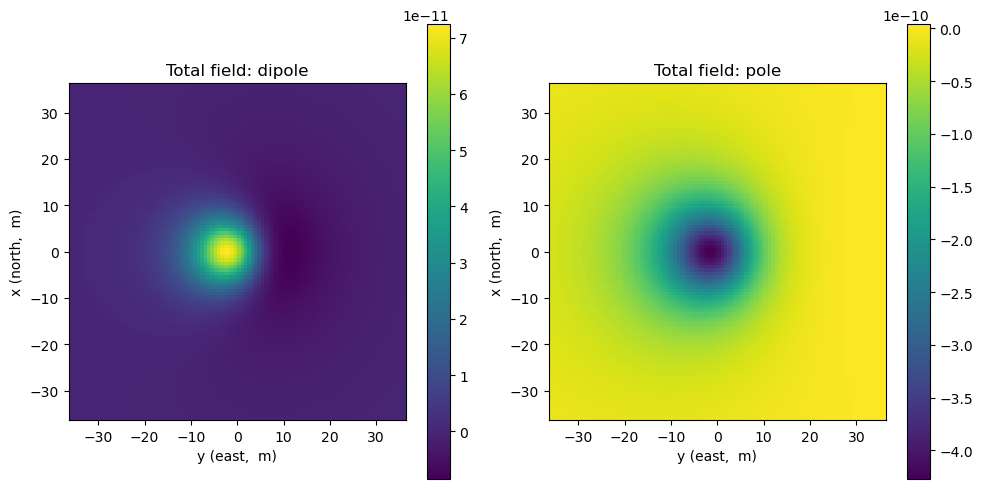

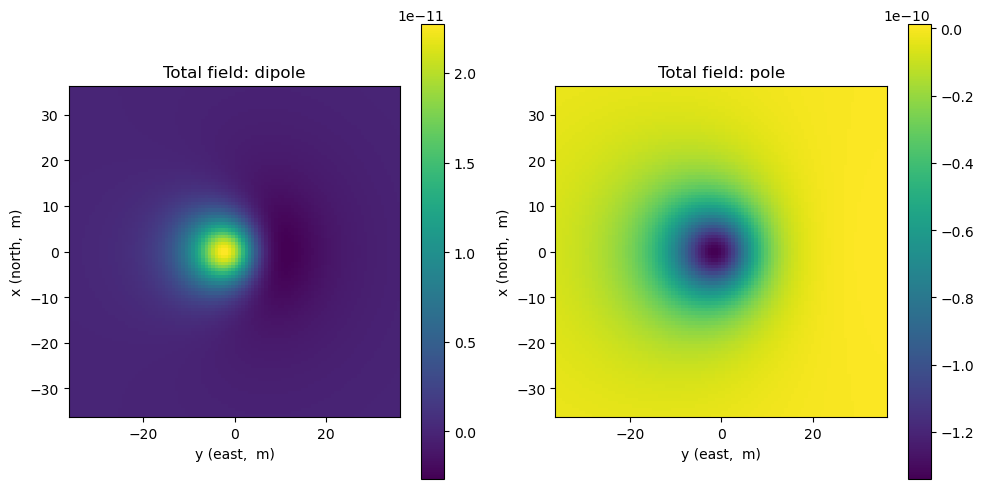

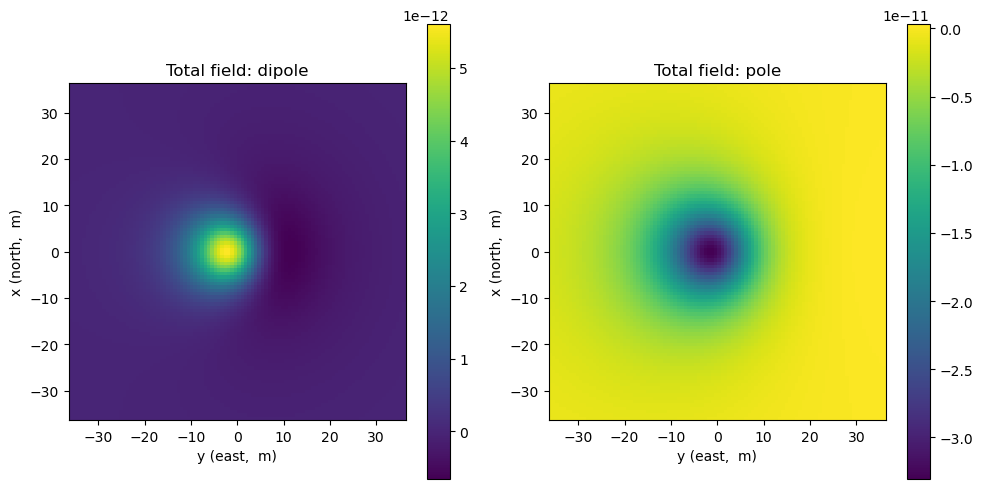

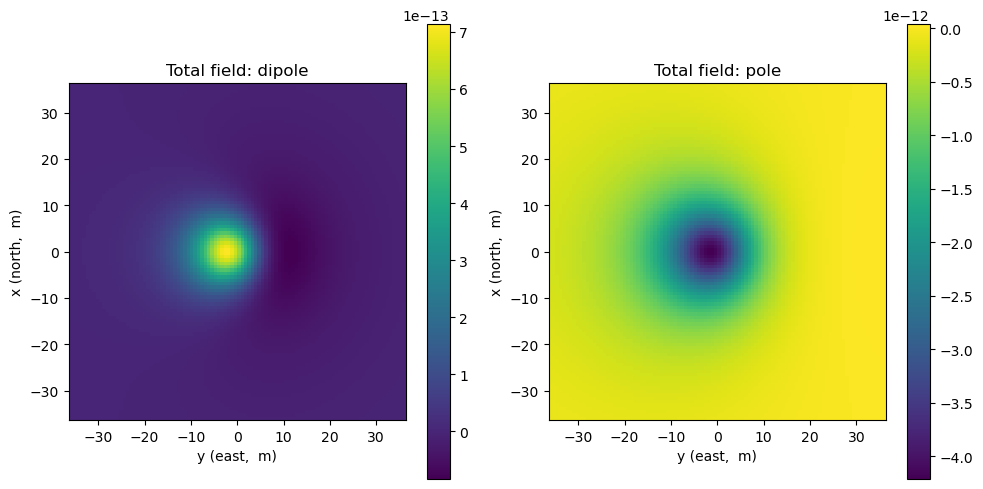

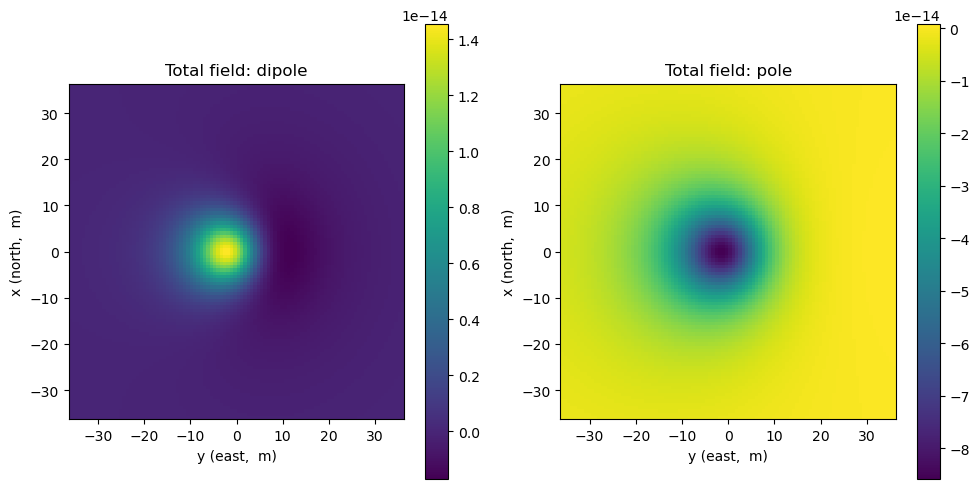

In [8]:
for val in L:
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    b_vec_dipole = val * dipole.magnetic_flux_density(xyz)
    b_vec_pole = val * pole.magnetic_flux_density(xyz)
    b_total_dipole = dipole.dot_orientation(b_vec_dipole)
    b_total_pole = pole.dot_orientation(b_vec_pole)
    
    #vector potentials
    plot_amplitude(ax[0], b_total_dipole)
    plot_amplitude(ax[1], b_total_pole)
    ax[0].set_title('Total field: dipole')
    ax[1].set_title('Total field: pole')
    plt.tight_layout()
    plt.show()

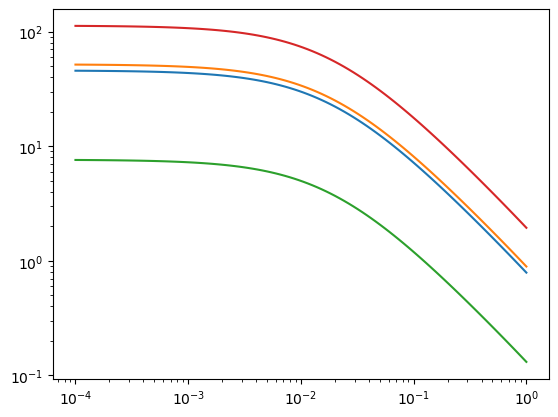

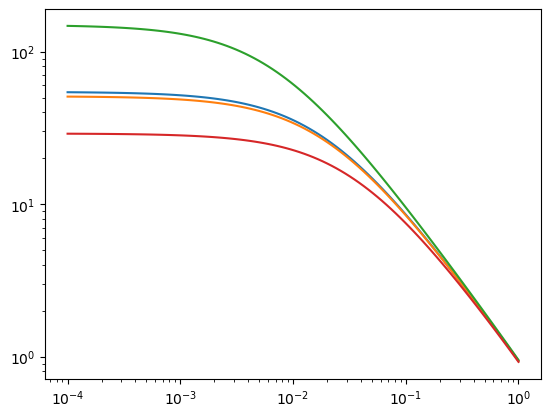

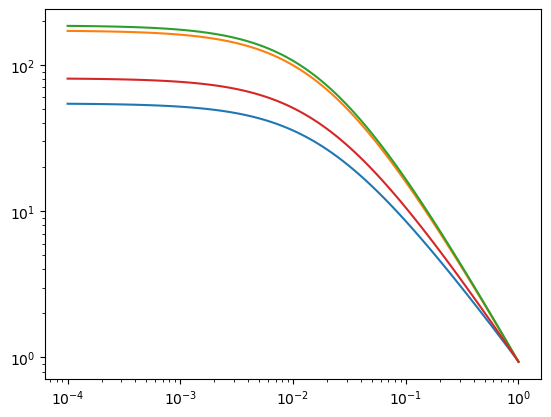

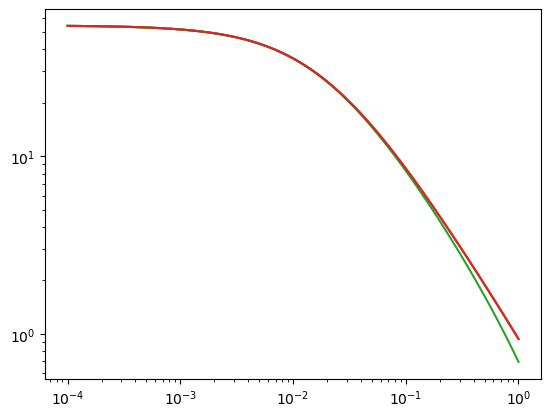

In [9]:
#recreate plots from Len Pasion thesis
t = np.logspace(-4, 0, 100)
alpha = 0.0191
beta = 1.01
gamma = 22.4
k = 1

k_vals = [0.841,0.951,0.140,2.07]
alpha_vals = [0.0191,0.0204,0.00702, 0.0356]
beta_vals = [1.01,1.30,1.32,1.11]
gamma_vals = [22.4,22.6,2.92, 22.2]

for val in k_vals:
    L = decay_law(t, val, alpha, beta, gamma)
    plt.loglog(t, L)
plt.show()
for val in alpha_vals:
    L = decay_law(t, k, val, beta, gamma)
    plt.loglog(t, L)
plt.show()
for val in beta_vals:
    L = decay_law(t, k, alpha, val, gamma)
    plt.loglog(t, L)
plt.show()
for val in gamma_vals:
    L = decay_law(t, k, alpha, beta, val)
    plt.loglog(t, L)
plt.show()

In [10]:
def decay_law(t, k, alpha, beta, gamma):
    return k * (t + alpha)**(-beta) * np.exp(-t / gamma)
def magnetic_sphere_em(x, y, z_obs,
                       x0, y0, z0,
                       a,
                       Bp,
                       t,
                       k, alpha, beta, gamma):
    
    # Geometry
    dx = x - x0
    dy = y - y0
    dz = z_obs - z0
    R = np.sqrt(dx**2 + dy**2 + dz**2)
    R[R == 0] = 1e-10
    cos_theta = dz / R
    sin_theta = np.sqrt(dx**2 + dy**2) / R
    
    #decay law from Len Pasion thesis
    L = decay_law(t, k, alpha, beta, gamma)
    
    # Spherical components (from your equation)
    B_r = Bp * (a**3 / R**3) * cos_theta * L
    B_theta = Bp * (a**3 / (2 * R**3)) * sin_theta * L
    
    # Convert to vertical component
    Bz = B_r * cos_theta - B_theta * sin_theta
    return Bz

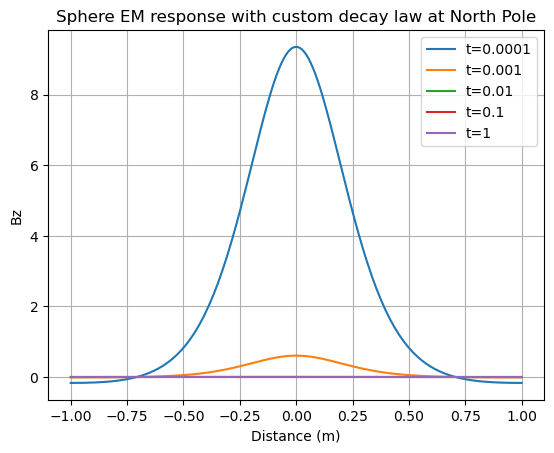

In [11]:
#check if working
x = np.linspace(-1, 1, 200)
y = np.zeros_like(x)
params = dict(
    x0=0, y0=0, z0=-0.5,
    a=0.015,
    Bp=1,
    k=1,
    alpha=1e-4,
    beta=1.5,
    gamma=0.005
)

plt.figure()
for ti in [1e-4, 1e-3, 1e-2, 1e-1,1]:
    dBz = magnetic_sphere_em(
        x, y, 0,
        t=ti,
        **params
    )
    plt.plot(x, dBz, label=f't={ti}')

plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Bz')
plt.title('Sphere EM response with custom decay law at North Pole')
plt.grid()
plt.show()

xyz shape: (625, 3)
x range: -36.0 36.0
y range: -36.0 36.0
Rotation matrix:
 [[ 0.39073113  0.          0.92050485]
 [ 0.         -1.          0.        ]
 [ 0.92050485  0.         -0.39073113]]
Long axis : [0.39073113 0.         0.92050485]
Cross axis 1: [ 0. -1.  0.]
Cross axis 2: [ 0.92050485  0.         -0.39073113]
Dot products (should be 0ish): 0.0 -1.1576395094682516e-17 0.0
t=1.00e-03  total range: -1.237e-09 to 6.811e-09


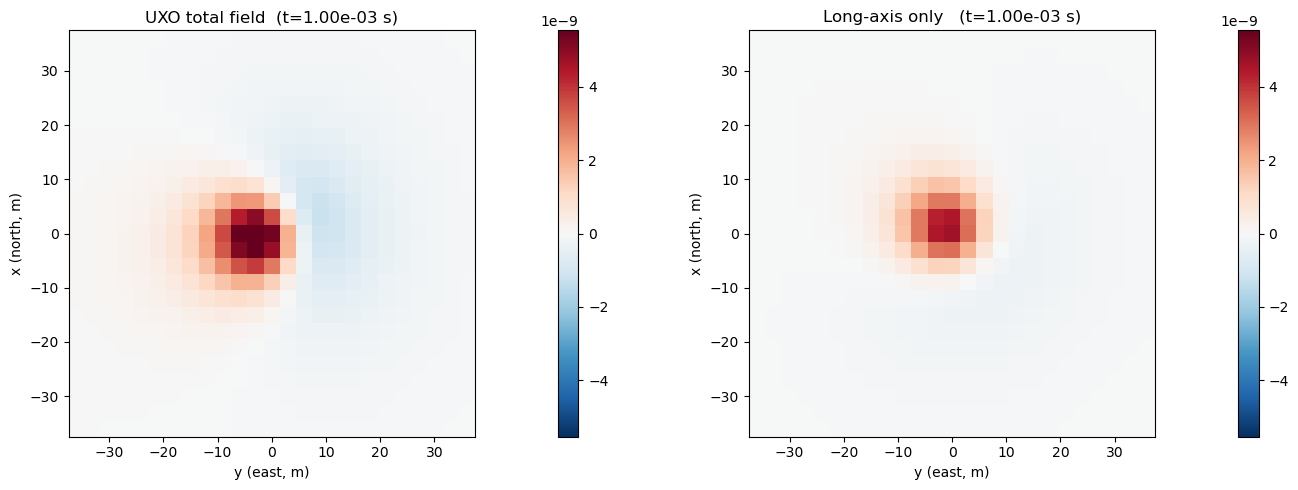

t=1.52e-03  total range: -1.125e-09 to 6.510e-09


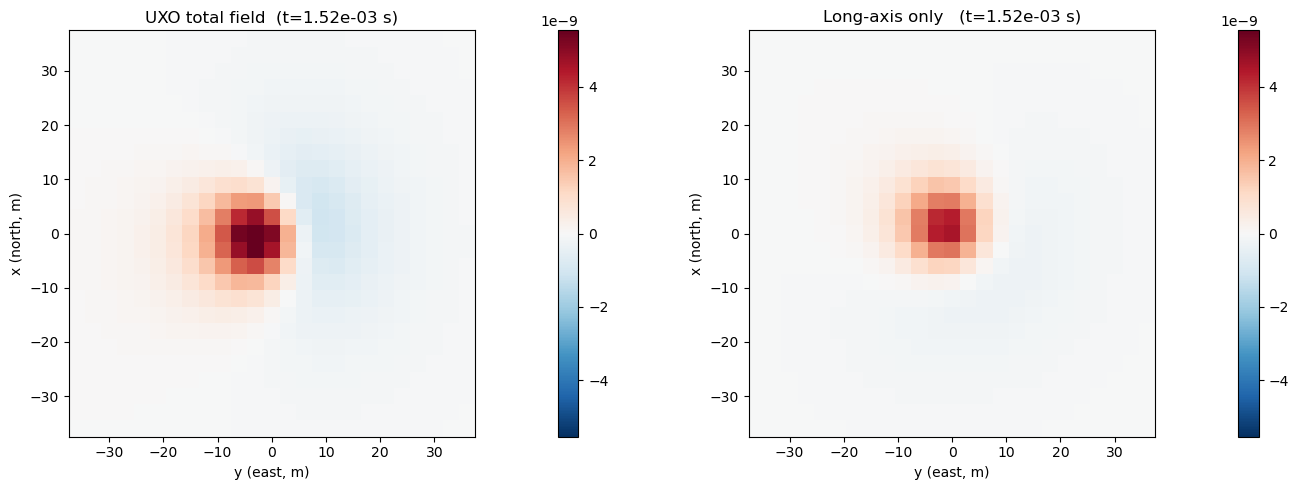

t=2.31e-03  total range: -9.820e-10 to 6.109e-09


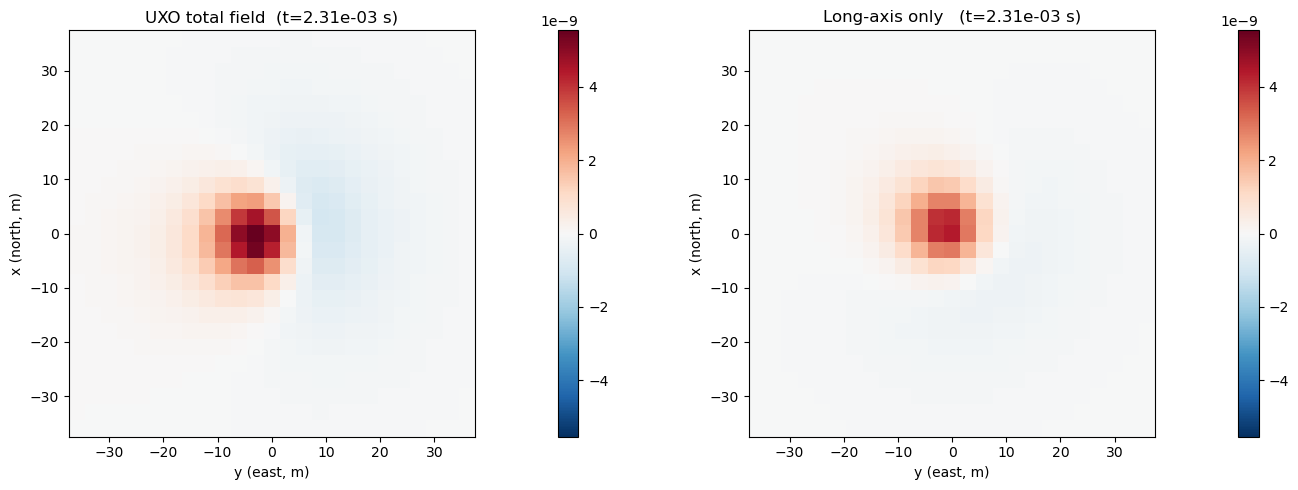

t=3.51e-03  total range: -8.138e-10 to 5.599e-09


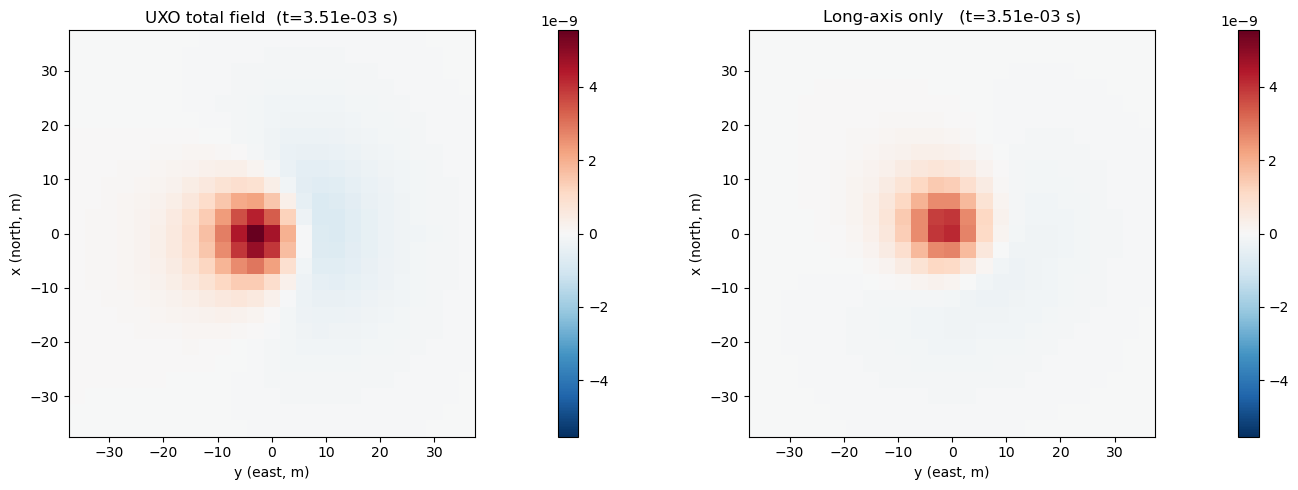

t=5.34e-03  total range: -6.657e-10 to 4.987e-09


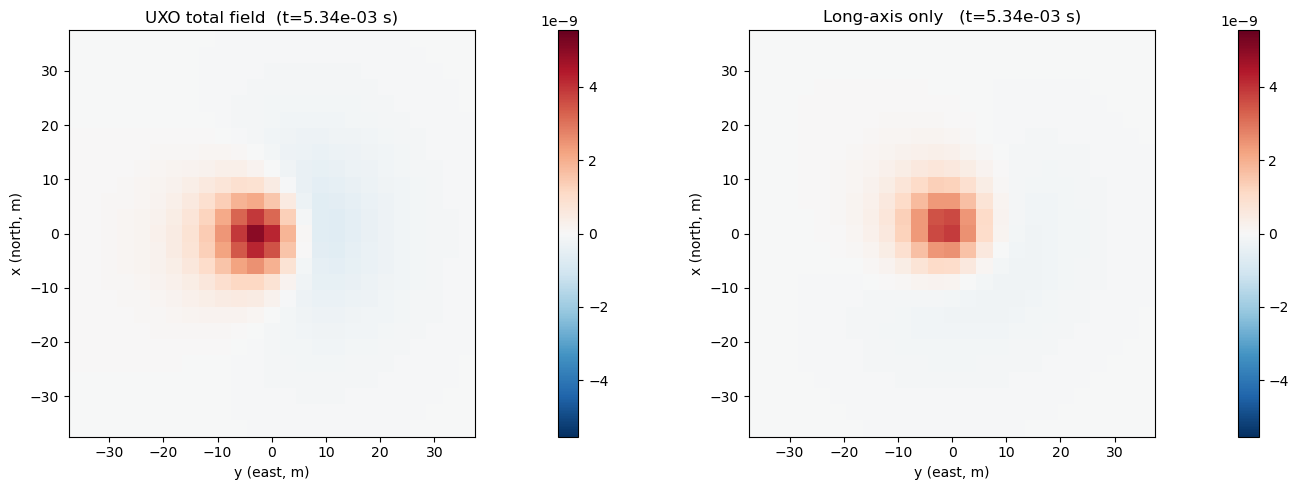

t=8.11e-03  total range: -5.298e-10 to 4.297e-09


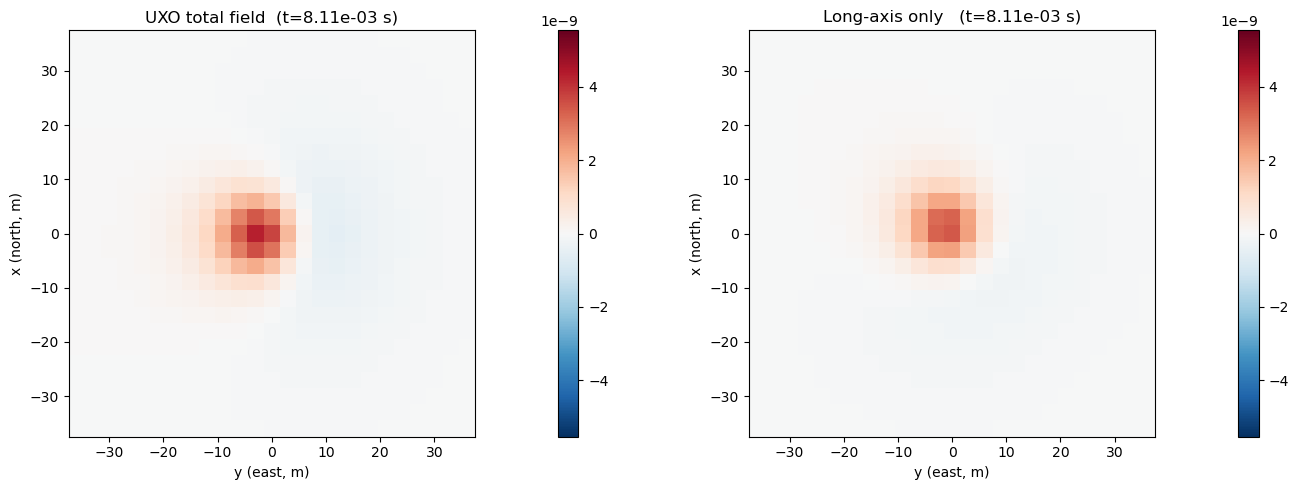

t=1.23e-02  total range: -4.025e-10 to 3.570e-09


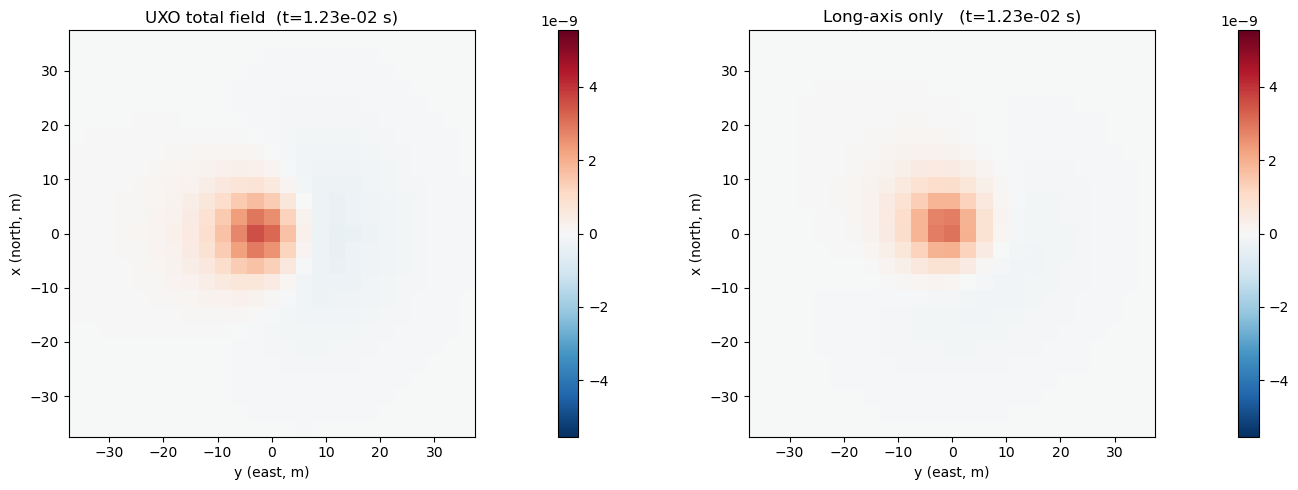

t=1.87e-02  total range: -2.930e-10 to 2.853e-09


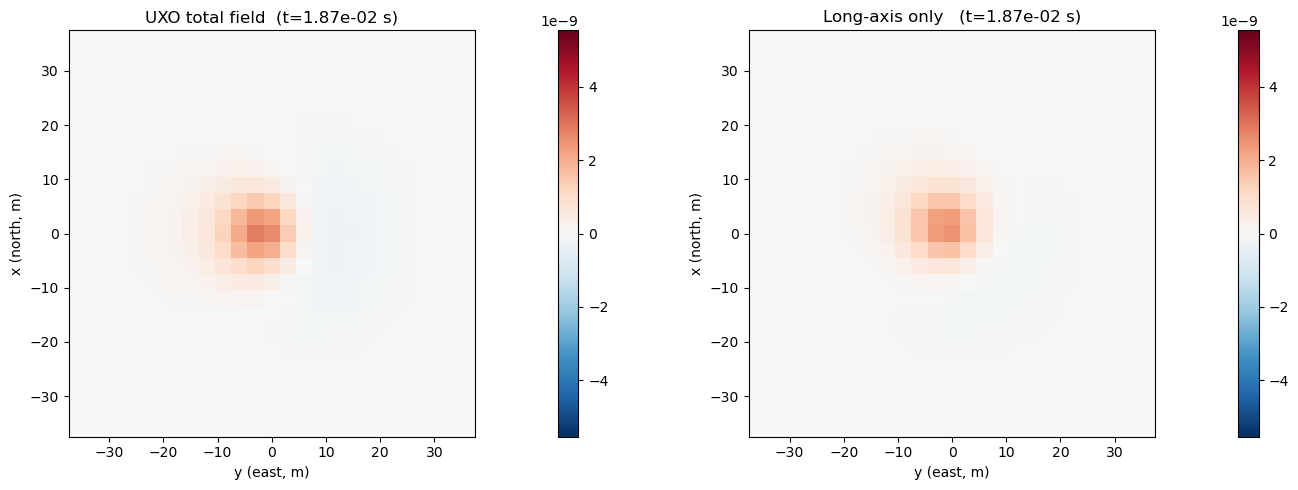

t=2.85e-02  total range: -2.096e-10 to 2.192e-09


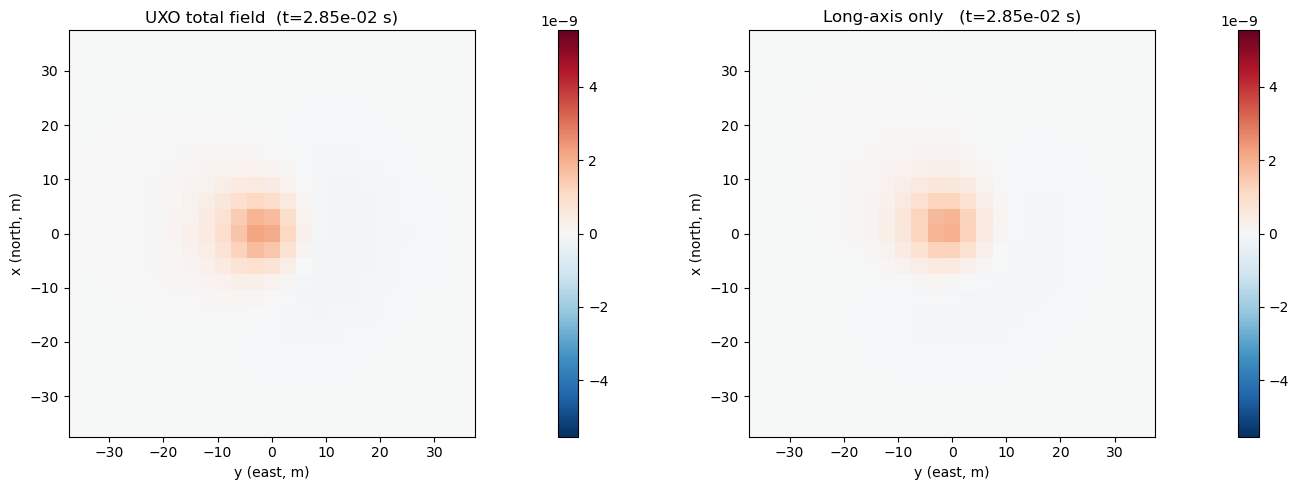

t=4.33e-02  total range: -1.458e-10 to 1.623e-09


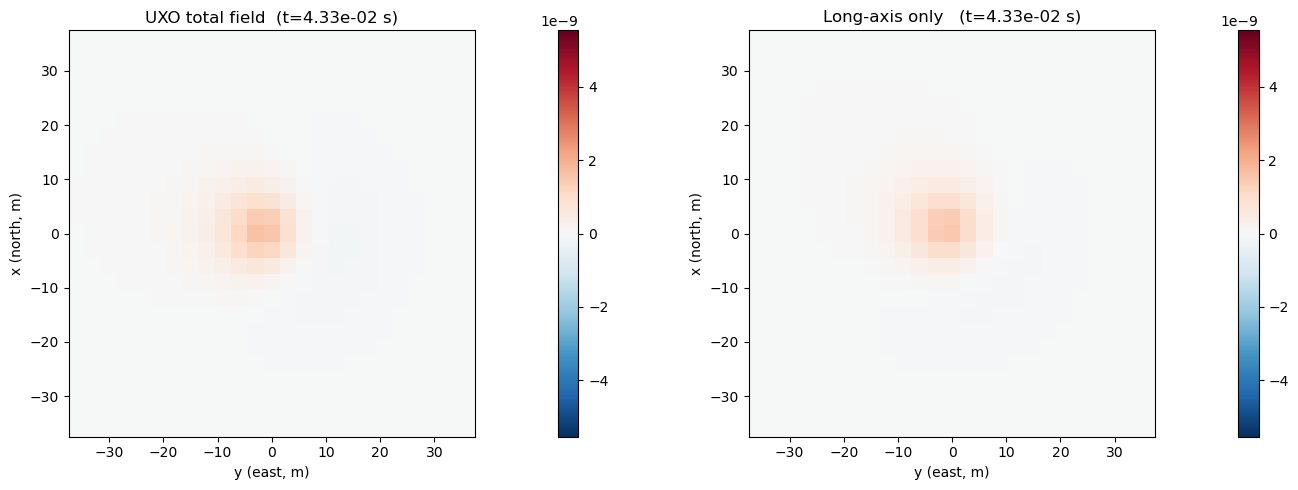

t=6.58e-02  total range: -9.876e-11 to 1.163e-09


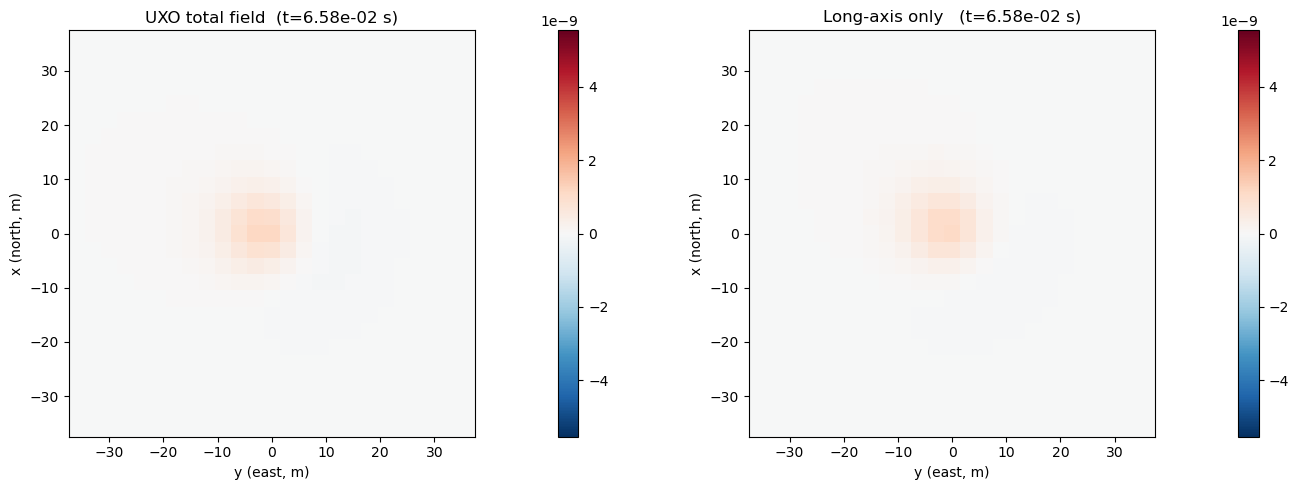

t=1.00e-01  total range: -6.666e-11 to 8.103e-10


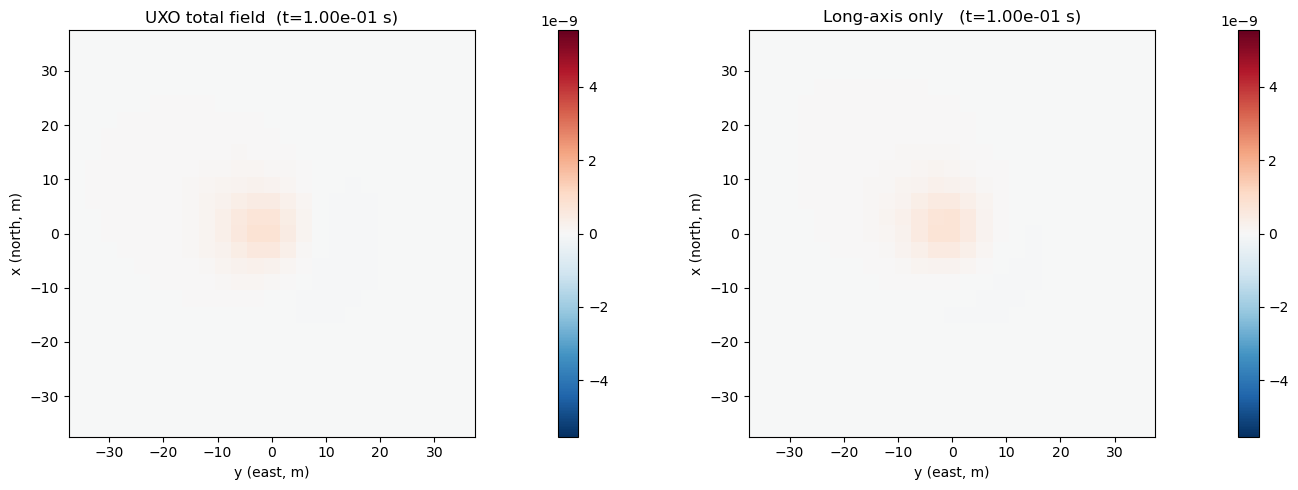

In [12]:
#grid creation
x_grid = np.linspace(-36, 36, 25)
y_grid = np.linspace(-36, 36, 25)

xyz = utils.ndgrid([x_grid, y_grid, np.r_[1.]]) #1
print('xyz shape:', xyz.shape)
print('x range:', xyz[:,0].min(), xyz[:,0].max())
print('y range:', xyz[:,1].min(), xyz[:,1].max())

#optional vmax
def plot_amplitude_sym(ax, v, title='', vmax=None):
    if vmax is None:
        vmax = np.abs(v).max()
    if vmax == 0: vmax = 1
    im = ax.pcolormesh(
        x_grid, y_grid, v.reshape(len(x_grid), len(y_grid), order='F'),
        cmap='RdBu_r', vmin=-vmax, vmax=vmax
    )
    plt.colorbar(im, ax=ax)
    ax.axis('square')
    ax.set_xlabel('y (east, m)')
    ax.set_ylabel('x (north, m)')
    ax.set_title(title)

# Decay parameters from Len Pasion Thesis
np.logspace(-3, -1, 6)
k1, alpha1, beta1, gamma1 = 0.841, 0.0191, 1.01, 22.4
k2, alpha2, beta2, gamma2 = 0.140, 0.00702, 1.32, 2.92
k3, alpha3, beta3, gamma3 = 0.140, 0.00702, 1.32, 2.92

# Earth's field direction (fixed - Vancouver)
inclination_earth, declination_earth = 67., 0.
earth_hat = id_to_cartesian(inclination_earth, declination_earth)

# UXO long axis orientation 
inclination_uxo, declination_uxo = 67., 0. #chose same as above
long_axis = id_to_cartesian(inclination_uxo, declination_uxo)

#rigid body rotation 
def rotation_matrix_from_inc_dec(inc_deg, dec_deg):
    inc = np.deg2rad(inc_deg)
    dec = np.deg2rad(dec_deg)

    # Unit vector for long axis direction
    z_axis = np.array([
        np.cos(inc) * np.cos(dec),
        np.cos(inc) * np.sin(dec),
        np.sin(inc) ])

    # Build orthonormal frame
    #reference vector not parallel to z_axis
    ref = np.array([0., 0., 1.]) if abs(z_axis[2]) < 0.9 else np.array([1., 0., 0.])
    x_axis = np.cross(ref, z_axis)
    x_axis /= np.linalg.norm(x_axis)
    y_axis = np.cross(z_axis, x_axis)
    y_axis /= np.linalg.norm(y_axis)

    # Rotation matrix where columns = body axes in world coordinates
    R = np.column_stack((z_axis, x_axis, y_axis))
    return R

#rotation matrix
R = rotation_matrix_from_inc_dec(inclination_uxo, declination_uxo)

# Object axis, rigid rotation
long_axis = R[:, 0]
cross1 = R[:, 1]
cross2 = R[:, 2]

print('Rotation matrix:\n', R)
print('Long axis :', long_axis)
print('Cross axis 1:', cross1)
print('Cross axis 2:', cross2)
print('Dot products (should be 0ish):', long_axis @ cross1, long_axis @ cross2, cross1 @ cross2)

# Dipoles
location = np.r_[0., 0., -10.]
dipole_long = static.MagneticDipoleWholeSpace(location=location, orientation=long_axis, moment=1)
dipole_cross1 = static.MagneticDipoleWholeSpace(location=location, orientation=cross1, moment=1)
dipole_cross2 = static.MagneticDipoleWholeSpace(location=location, orientation=cross2, moment=1)

#Get global color scale from the first time step
t_plot = np.logspace(-3, -1, 12) #thought this time looked the best.
L1_first = decay_law(t_plot[0], k1, alpha1, beta1, gamma1)
b_long_first = L1_first * dipole_long.magnetic_flux_density(xyz)
global_vmax = np.abs(b_long_first @ earth_hat).max()

#loop over time gates
for ti in t_plot:
    L1_t = decay_law(ti, k1, alpha1, beta1, gamma1)
    L2_t = decay_law(ti, k2, alpha2, beta2, gamma2)
    L3_t = decay_law(ti, k3, alpha3, beta3, gamma3)

    # Excitation projections
    H_long = earth_hat @ long_axis
    H_cross1 = earth_hat @ cross1
    H_cross2 = earth_hat @ cross2

    # each dipole moment = (polarizability decay) * (excitation along that axis)
    b_long = (L1_t * H_long) * dipole_long.magnetic_flux_density(xyz)
    b_cross1 = (L2_t * H_cross1) * dipole_cross1.magnetic_flux_density(xyz)
    b_cross2 = (L3_t * H_cross2) * dipole_cross2.magnetic_flux_density(xyz)

    b_total_vec = b_long + b_cross1 + b_cross2
    total = b_total_vec @ earth_hat
    long_only = b_long @ earth_hat

    print(f't={ti:.2e}  total range: {total.min():.3e} to {total.max():.3e}')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_amplitude_sym(axes[0], total,f'UXO total field  (t={ti:.2e} s)', vmax=global_vmax)
    plot_amplitude_sym(axes[1], long_only,f'Long-axis only   (t={ti:.2e} s)', vmax=global_vmax)
    plt.tight_layout()
    plt.show()

In [13]:
#forward model  
def dipole_model(x):
    x0, y0, z0, inc, dec = x
 
    R_mat = rotation_matrix_from_inc_dec(inc, dec)
    long_axis = R_mat[:, 0]
    cross1 = R_mat[:, 1]
    cross2 = R_mat[:, 2]
 
    location = np.r_[x0, y0, z0]
 
    dip_long = static.MagneticDipoleWholeSpace(location=location, orientation=long_axis, moment=1)
    dip_cross1 = static.MagneticDipoleWholeSpace(location=location, orientation=cross1, moment=1)
    dip_cross2 = static.MagneticDipoleWholeSpace(location=location, orientation=cross2, moment=1)
 
    H_long = earth_hat @ long_axis
    H_cross1 = earth_hat @ cross1
    H_cross2 = earth_hat @ cross2
 
    dpred_all = []
    for ti in t_plot:
        L1 = decay_law(ti, k1, alpha1, beta1, gamma1)
        L2 = decay_law(ti, k2, alpha2, beta2, gamma2)
        L3 = decay_law(ti, k3, alpha3, beta3, gamma3)
 
        b = ((L1 * H_long) * dip_long.magnetic_flux_density(xyz)
           + (L2 * H_cross1) * dip_cross1.magnetic_flux_density(xyz)
           + (L3 * H_cross2) * dip_cross2.magnetic_flux_density(xyz))
 
        dpred_all.append(b @ earth_hat)
 
    return np.hstack(dpred_all)

 

beta=1.00e+05  phi_d=1.081e+04  phi_m=1.953e-02 -> [ 0.25 -0.36 -7.32 60.62  9.71]
beta=4.52e+04  phi_d=9.514e+03  phi_m=3.893e-02 -> [ 0.44 -0.63 -7.81 60.89  9.75]
beta=2.04e+04  phi_d=8.604e+03  phi_m=6.886e-02 -> [ 0.74 -1.01 -8.29 61.16  9.96]
beta=9.24e+03  phi_d=8.042e+03  phi_m=1.093e-01 -> [ 1.13 -1.48 -8.71 61.34 10.45]
beta=4.18e+03  phi_d=7.751e+03  phi_m=1.551e-01 -> [ 1.54 -1.94 -9.05 61.22 11.29]
beta=1.89e+03  phi_d=7.627e+03  phi_m=1.974e-01 -> [ 1.87 -2.3  -9.3  60.53 12.67]
beta=8.53e+02  phi_d=7.581e+03  phi_m=2.328e-01 -> [ 2.08 -2.53 -9.49 58.92 14.93]
beta=3.86e+02  phi_d=7.560e+03  phi_m=2.677e-01 -> [ 2.19 -2.66 -9.66 56.29 18.12]
beta=1.74e+02  phi_d=7.550e+03  phi_m=3.087e-01 -> [ 2.22 -2.75 -9.8  53.22 21.6 ]
beta=7.88e+01  phi_d=7.544e+03  phi_m=3.501e-01 -> [ 2.22 -2.8  -9.91 50.57 24.45]
beta=3.56e+01  phi_d=7.543e+03  phi_m=3.822e-01 -> [ 2.2  -2.84 -9.98 48.76 26.3 ]
beta=1.61e+01  phi_d=7.542e+03  phi_m=4.020e-01 -> [  2.19  -2.86 -10.01  47.72  27.32]

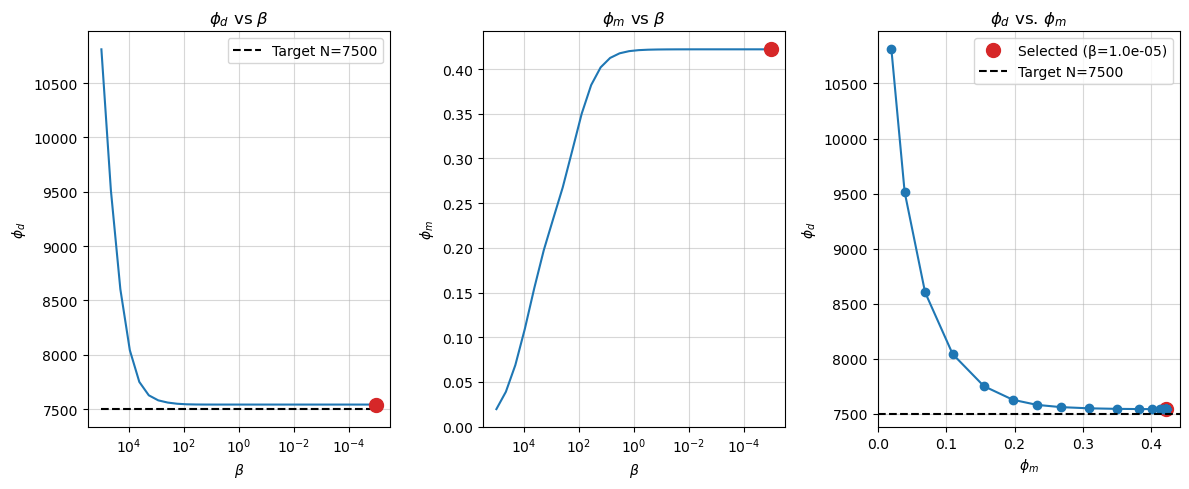


Picked iteration 29, (beta = 1.000e-05)
  phi_d = 7.542e+03, (target = 7500)


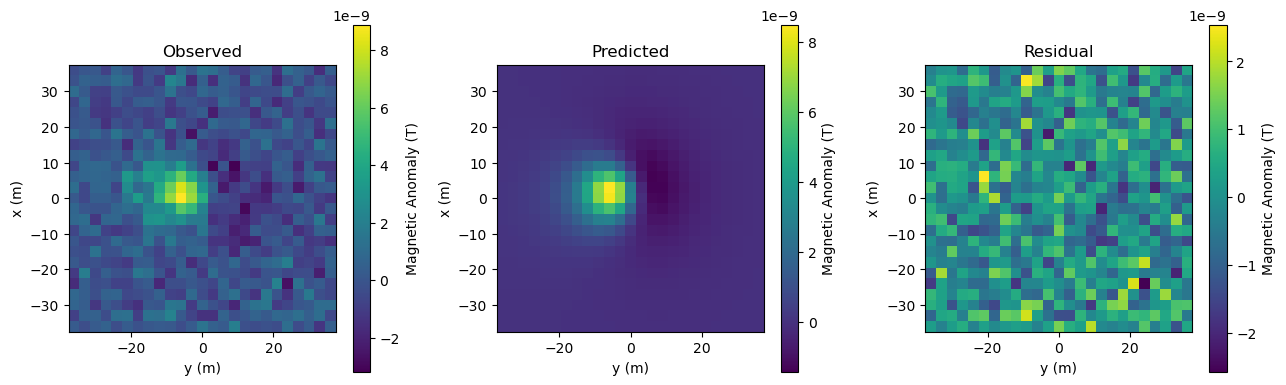


Recovered parameters:
  x0 (m)       = 2.177
  y0 (m)       = -2.874
  z0 (m)       = -10.048
  inc (deg)    = 46.724
  dec (deg)    = 28.287


In [14]:
#dobs 

x_true = np.array([2., -3., -10., 45., 30.]) #target parameters #2 -3 -10 45 30,    30 -30 -5 75 6
dobs = dipole_model(x_true)

noise_level = 0.1
rng = np.random.default_rng(42)
dobs = dobs + noise_level * np.max(np.abs(dobs)) * rng.standard_normal(dobs.size)
 
# compute noise level from clean data (before noise was added)
clean_data = dipole_model(x_true)
noise_std = noise_level * np.max(np.abs(clean_data))
epsilon = noise_std * np.ones(dobs.size)

#least squares target
phid_star = len(dobs)
 
# reference model and parameter scales
x_ref = np.array([0., 0, -6., 60., 10.]) # starting guess was #0, 0 
param_scales = np.array([10., 10., 10., 45., 90.])  # normalise m vs degrees
 
bounds = [(-50, 50), (-50, 50), (-50, 0), # x0, y0, z0, need z<0 so its actually underground
          (0,   90), (-180, 180)] # inc, dec
  
#beta sweep
betas  = np.logspace(5, -5, 30)

phi_d_list  = []
phi_m_list  = []
models_list = []

x_start = x_ref.copy()
for beta in betas:
    def residual(x):
        dpred = dipole_model(x)
        # data misfit part
        r_d = (dpred - dobs) / epsilon
        # model regularization part
        r_m = np.sqrt(beta) * (x - x_ref) / param_scales
        return np.hstack([r_d, r_m])

    result = least_squares(
        residual, x_start, bounds=np.array(bounds).T, max_nfev=500, ftol=1e-12, xtol=1e-12, gtol=1e-12
    )

    x_sol = result.x
    x_start = x_sol.copy()
    
    #phi d and m 
    dpred = dipole_model(x_sol)
    phi_d = np.sum(((dpred - dobs) / epsilon) ** 2)
    phi_m = np.sum(((x_sol - x_ref) / param_scales) ** 2)
    phi_d_list.append(phi_d)
    phi_m_list.append(phi_m)
    models_list.append(x_sol)
    print(f"beta={beta:.2e}  phi_d={phi_d:.3e}  phi_m={phi_m:.3e} -> {np.round(x_sol, 2)}")
    
phi_d_arr = np.array(phi_d_list)
phi_m_arr = np.array(phi_m_list)
 
 
#Tikhonov curves 
def plot_tikhonov_curves(beta_values, phi_d, phi_m, phid_star=None, iteration=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 3, figsize=(12, 5))

    ax[0].semilogx(beta_values, phi_d)
    ax[1].semilogx(beta_values, phi_m)
    if phid_star is not None:
        ax[0].plot(beta_values, np.ones_like(beta_values) * phid_star, '--k', label=f'Target N={phid_star}')

    if iteration is not None:
        ax[0].plot(beta_values[iteration], phi_d[iteration], 'C3o', ms=10)
        ax[1].plot(beta_values[iteration], phi_m[iteration], 'C3o', ms=10)
        ax[2].plot(phi_m[iteration], phi_d[iteration], 'C3o', ms=10, label=f'Selected (β={beta_values[iteration]:.1e})')

    ax[0].set_ylabel(r'$\phi_d$')
    ax[0].set_xlabel(r'$\beta$')
    ax[0].set_title(r'$\phi_d$ vs $\beta$') 
    ax[1].set_ylabel(r'$\phi_m$')
    ax[1].set_xlabel(r'$\beta$')
    ax[1].set_title(r'$\phi_m$ vs $\beta$')

    ax[2].plot(phi_m, phi_d, 'o-')
    if phid_star is not None:
        ax[2].axhline(phid_star, ls='--', color='k', label=f'Target N={phid_star}')
    ax[2].set_xlabel(r'$\phi_m$')
    ax[2].set_ylabel(r'$\phi_d$')
    ax[2].set_title(r'$\phi_d$ vs. $\phi_m$')
    ax[2].legend()

    for a in ax[:2]:
        a.invert_xaxis()
        a.grid(which='both', alpha=0.5)
    ax[2].grid(which='both', alpha=0.5)

    ax[0].legend()
    plt.tight_layout()
    return ax
 
# pick iteration
acceptable = np.where(phi_d_arr <= phid_star)[0]
iteration  = int(acceptable[0]) if len(acceptable) else len(betas) - 1
ax = plot_tikhonov_curves(betas, phi_d_arr, phi_m_arr, phid_star=phid_star, iteration=iteration)
plt.show()
 
print(f"\nPicked iteration {iteration}, (beta = {betas[iteration]:.3e})")
print(f"  phi_d = {phi_d_arr[iteration]:.3e}, (target = {phid_star})")
 
 
#obs vs pred
x_recovered = models_list[iteration]
dpred = dipole_model(x_recovered)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for i, (dplot, title) in enumerate([
    (dobs, 'Observed'),
    (dpred, 'Predicted'),
    (dobs - dpred, 'Residual')
]):
    im = ax[i].pcolormesh(
        x_grid, y_grid,
        dplot[:len(x_grid)*len(y_grid)].reshape(len(x_grid), len(y_grid), order='F')
    )
    cbar = plt.colorbar(im, ax=ax[i]) # store it
    cbar.set_label('Magnetic Anomaly (T)')
    
    ax[i].set_title(title)
    ax[i].set_xlabel('y (m)')
    ax[i].set_ylabel('x (m)')
    ax[i].set_aspect('equal')


plt.tight_layout()
plt.show()

print("\nRecovered parameters:")
labels = ['x0 (m)', 'y0 (m)', 'z0 (m)', 'inc (deg)', 'dec (deg)']
for lbl, val in zip(labels, x_recovered):
    print(f"  {lbl:12s} = {val:.3f}")

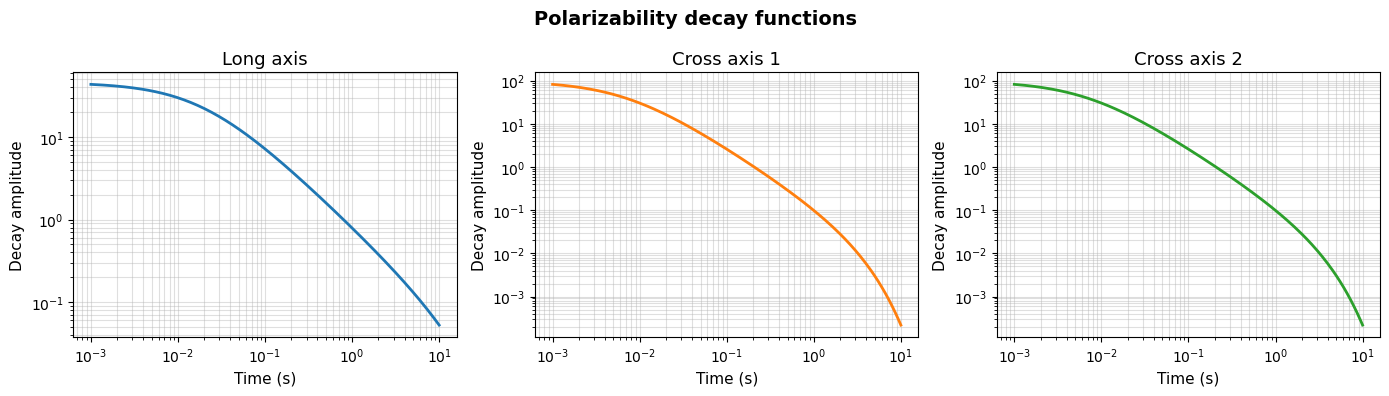

Decay parameters:
                      k     alpha      beta     gamma
 Long axis       0.8410    0.0191    1.0100   22.4000
 Cross axis 1    0.1400    0.0070    1.3200    2.9200
 Cross axis 2    0.1400    0.0070    1.3200    2.9200

True model parameters:
  x0 (m)       = 2.000
  y0 (m)       = -3.000
  z0 (m)       = -10.000
  inc (deg)    = 45.000
  dec (deg)    = 30.000


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

decay_params = [
    (k1, alpha1, beta1, gamma1, 'Long axis',  'C0'),
    (k2, alpha2, beta2, gamma2, 'Cross axis 1', 'C1'),
    (k3, alpha3, beta3, gamma3, 'Cross axis 2', 'C2'),
]

t_decay = np.logspace(-3, 1, 200)
for ax, (k, alpha, beta, gamma, label, color) in zip(axes, decay_params):
    L = decay_law(t_decay, k, alpha, beta, gamma)
    ax.loglog(t_decay, L, color=color, lw=2)
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Decay amplitude', fontsize=11)
    ax.grid(which='both', alpha=0.4)

plt.suptitle('Polarizability decay functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Decay parameters:")
print(f" {'':12s}  {'k':>8}  {'alpha':>8}  {'beta':>8}  {'gamma':>8}")
print(f" {'Long axis':12s}  {k1:>8.4f}  {alpha1:>8.4f}  {beta1:>8.4f}  {gamma1:>8.4f}")
print(f" {'Cross axis 1':12s}  {k2:>8.4f}  {alpha2:>8.4f}  {beta2:>8.4f}  {gamma2:>8.4f}")
print(f" {'Cross axis 2':12s}  {k3:>8.4f}  {alpha3:>8.4f}  {beta3:>8.4f}  {gamma3:>8.4f}")

print("\nTrue model parameters:")
labels = ['x0 (m)', 'y0 (m)', 'z0 (m)', 'inc (deg)', 'dec (deg)']
for lbl, val in zip(labels, x_true):
    print(f"  {lbl:12s} = {val:.3f}")